# Exploratory Data Analysis — Credit Risk Dataset

Understand the training data before building a challenger model.

**What this notebook covers:**
- Dataset size, default rate, class imbalance
- Feature distributions and outliers
- Correlation structure
- Default rate by feature segment
- Prediction history overview (what the model has seen in production)

In [1]:
import os
import warnings
warnings.filterwarnings('ignore')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from sqlalchemy import create_engine

POSTGRES_HOST = os.getenv('POSTGRES_HOST', 'postgres')
POSTGRES_PORT = os.getenv('POSTGRES_PORT', '5432')
POSTGRES_DB   = os.getenv('POSTGRES_DB', 'mlops')
POSTGRES_USER = os.getenv('POSTGRES_USER', 'mlops_user')
POSTGRES_PASS = os.getenv('POSTGRES_PASSWORD', '')

engine = create_engine(
    f'postgresql+psycopg2://{POSTGRES_USER}:{POSTGRES_PASS}'
    f'@{POSTGRES_HOST}:{POSTGRES_PORT}/{POSTGRES_DB}'
)

FEATURE_COLUMNS = [
    'age', 'annual_income', 'credit_score', 'loan_amount',
    'loan_term_months', 'employment_length_years', 'home_ownership_encoded',
    'debt_to_income_ratio', 'num_credit_lines', 'payment_history_score',
]
TARGET = 'default_flag'

print('Connections ready.')

Connections ready.


## 1  Dataset Overview

In [2]:
df = pd.read_sql(
    f"SELECT {', '.join(FEATURE_COLUMNS)}, {TARGET} "
    f"FROM dwh_clean.cleaned_features WHERE {TARGET} IS NOT NULL ORDER BY created_at",
    engine,
)

n_default = df[TARGET].sum()
n_total   = len(df)
print(f'Records:       {n_total:,}')
print(f'Defaults:      {n_default:,}  ({n_default/n_total:.1%})')
print(f'Non-defaults:  {n_total-n_default:,}  ({(n_total-n_default)/n_total:.1%})')
print(f'Imbalance ratio: 1 : {(n_total-n_default)/n_default:.1f}')

Records:       24,137
Defaults:      6,747  (28.0%)
Non-defaults:  17,390  (72.0%)
Imbalance ratio: 1 : 2.6


In [3]:
# Summary statistics split by outcome
desc = df.groupby(TARGET)[FEATURE_COLUMNS].mean().T
desc.columns = ['Non-Default (0)', 'Default (1)']
desc['Difference'] = desc['Default (1)'] - desc['Non-Default (0)']
desc['Diff %'] = (desc['Difference'] / desc['Non-Default (0)'] * 100).round(1)
desc.round(3)

,Non-Default (0),Default (1),Difference,Diff %
age,41.810,41.773,-0.037,-0.1
annual_income,72421.073,54552.863,-17868.211,-24.7
credit_score,685.823,662.332,-23.490,-3.4
loan_amount,22952.174,32034.479,9082.305,39.6
loan_term_months,44.421,43.559,-0.862,-1.9
employment_length_years,6.407,4.911,-1.496,-23.3
home_ownership_encoded,0.902,0.905,0.003,0.4
debt_to_income_ratio,0.381,0.738,0.357,93.5
num_credit_lines,8.032,8.080,0.048,0.6
payment_history_score,74.473,63.196,-11.277,-15.1


## 2  Feature Distributions

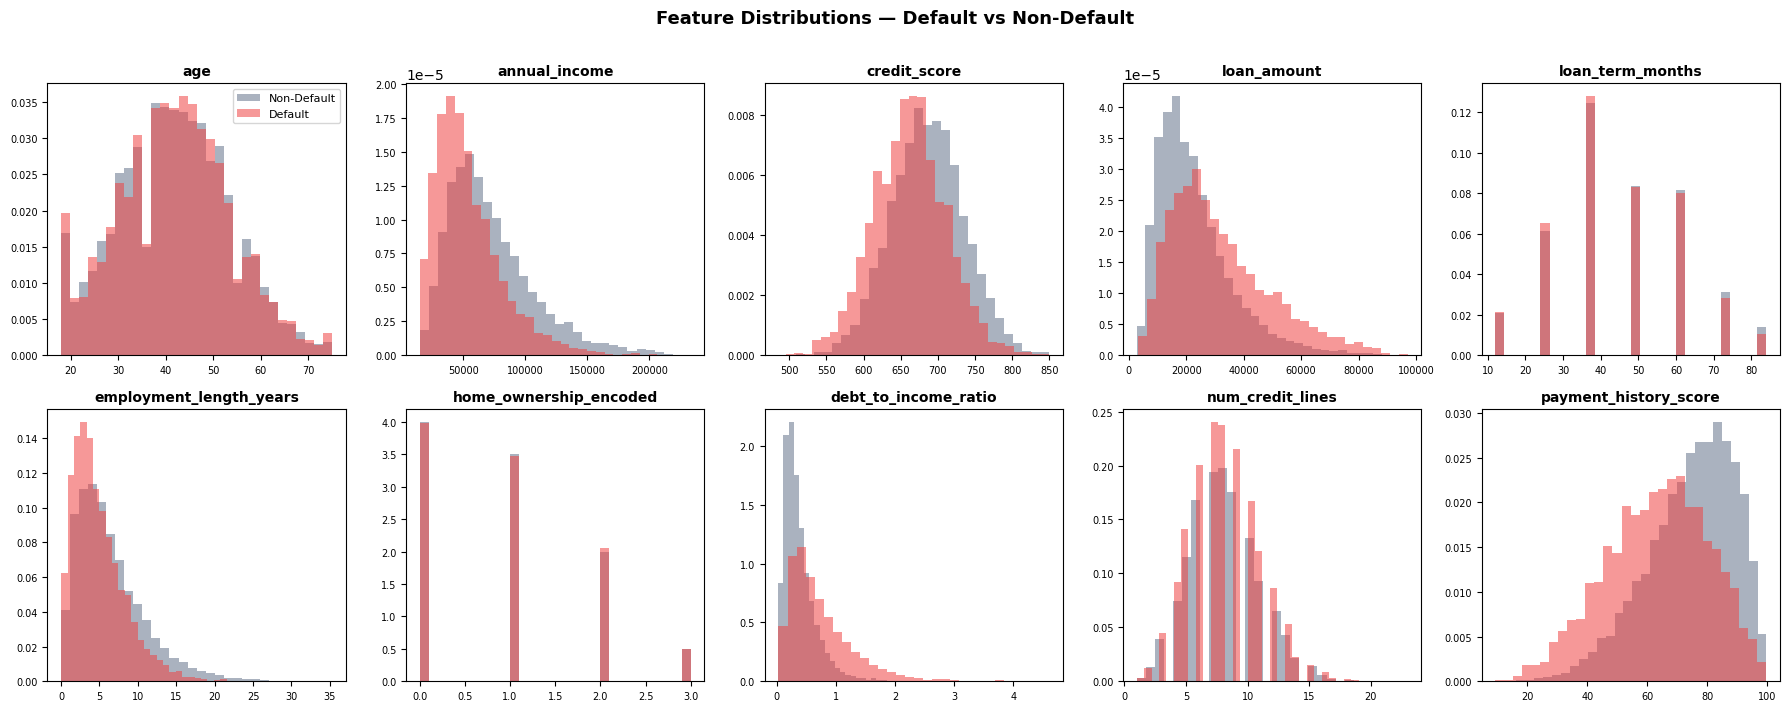

In [4]:
fig, axes = plt.subplots(2, 5, figsize=(18, 7))
axes = axes.flatten()

colors = {0: '#64748b', 1: '#ef4444'}
labels = {0: 'Non-Default', 1: 'Default'}

for ax, feat in zip(axes, FEATURE_COLUMNS):
    for outcome in [0, 1]:
        vals = df[df[TARGET] == outcome][feat].dropna()
        ax.hist(vals, bins=30, alpha=0.55, color=colors[outcome],
                label=labels[outcome], density=True)
    ax.set_title(feat, fontsize=10, fontweight='bold')
    ax.set_xlabel('')
    ax.tick_params(labelsize=7)

axes[0].legend(fontsize=8)
fig.suptitle('Feature Distributions — Default vs Non-Default', fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

## 3  Correlation Structure

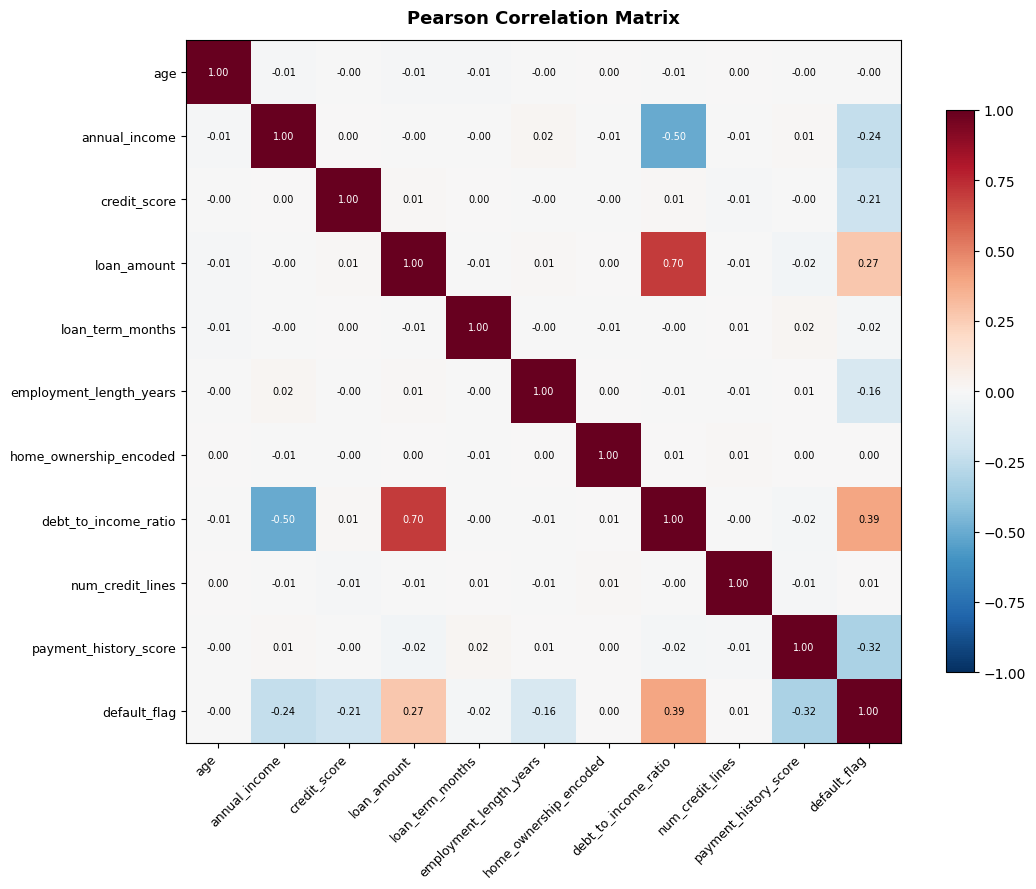


Top feature correlations with default_flag:
  debt_to_income_ratio             +0.3931
  payment_history_score            -0.3152
  loan_amount                      +0.2734
  annual_income                    -0.2362
  credit_score                     -0.2099
  employment_length_years          -0.1598
  loan_term_months                 -0.0227
  num_credit_lines                 +0.0077
  home_ownership_encoded           +0.0016
  age                              -0.0014


In [5]:
corr = df[FEATURE_COLUMNS + [TARGET]].corr()

fig, ax = plt.subplots(figsize=(11, 9))
im = ax.imshow(corr, cmap='RdBu_r', vmin=-1, vmax=1, aspect='auto')
plt.colorbar(im, ax=ax, shrink=0.8)

labels_all = FEATURE_COLUMNS + [TARGET]
ax.set_xticks(range(len(labels_all)))
ax.set_yticks(range(len(labels_all)))
ax.set_xticklabels(labels_all, rotation=45, ha='right', fontsize=9)
ax.set_yticklabels(labels_all, fontsize=9)

for i in range(len(labels_all)):
    for j in range(len(labels_all)):
        val = corr.iloc[i, j]
        ax.text(j, i, f'{val:.2f}', ha='center', va='center',
                fontsize=7, color='white' if abs(val) > 0.5 else 'black')

ax.set_title('Pearson Correlation Matrix', fontsize=13, fontweight='bold', pad=12)
plt.tight_layout()
plt.show()

# Show top correlates with target
print('\nTop feature correlations with default_flag:')
target_corr = corr[TARGET].drop(TARGET).abs().sort_values(ascending=False)
for feat, val in target_corr.items():
    sign = '+' if corr.loc[feat, TARGET] > 0 else '-'
    print(f'  {feat:<32} {sign}{val:.4f}')

## 4  Default Rate by Feature Segment

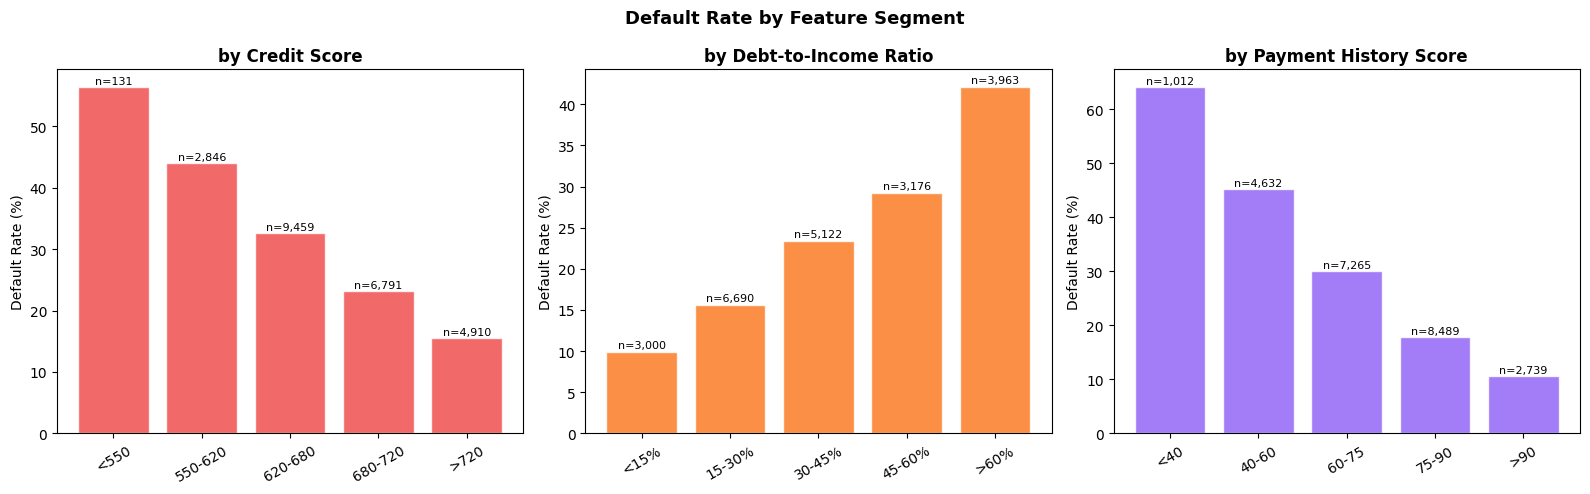

In [6]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# Credit score buckets
df['cs_bucket'] = pd.cut(df['credit_score'], bins=[300, 550, 620, 680, 720, 850],
                          labels=['<550', '550-620', '620-680', '680-720', '>720'])
rate = df.groupby('cs_bucket', observed=True)[TARGET].agg(['mean', 'count'])
axes[0].bar(range(len(rate)), rate['mean'] * 100, color='#ef4444', alpha=0.8, edgecolor='white')
axes[0].set_xticks(range(len(rate)))
axes[0].set_xticklabels(rate.index, rotation=30)
axes[0].set_ylabel('Default Rate (%)')
axes[0].set_title('by Credit Score', fontweight='bold')
for i, (_, row) in enumerate(rate.iterrows()):
    axes[0].text(i, row['mean']*100 + 0.5, f"n={int(row['count']):,}", ha='center', fontsize=8)

# DTI buckets
df['dti_bucket'] = pd.cut(df['debt_to_income_ratio'], bins=[0, 0.15, 0.30, 0.45, 0.60, 1.0],
                           labels=['<15%', '15-30%', '30-45%', '45-60%', '>60%'])
rate2 = df.groupby('dti_bucket', observed=True)[TARGET].agg(['mean', 'count'])
axes[1].bar(range(len(rate2)), rate2['mean'] * 100, color='#f97316', alpha=0.8, edgecolor='white')
axes[1].set_xticks(range(len(rate2)))
axes[1].set_xticklabels(rate2.index, rotation=30)
axes[1].set_ylabel('Default Rate (%)')
axes[1].set_title('by Debt-to-Income Ratio', fontweight='bold')
for i, (_, row) in enumerate(rate2.iterrows()):
    axes[1].text(i, row['mean']*100 + 0.5, f"n={int(row['count']):,}", ha='center', fontsize=8)

# Payment history score buckets
df['pay_bucket'] = pd.cut(df['payment_history_score'], bins=[0, 40, 60, 75, 90, 100],
                           labels=['<40', '40-60', '60-75', '75-90', '>90'])
rate3 = df.groupby('pay_bucket', observed=True)[TARGET].agg(['mean', 'count'])
axes[2].bar(range(len(rate3)), rate3['mean'] * 100, color='#8b5cf6', alpha=0.8, edgecolor='white')
axes[2].set_xticks(range(len(rate3)))
axes[2].set_xticklabels(rate3.index, rotation=30)
axes[2].set_ylabel('Default Rate (%)')
axes[2].set_title('by Payment History Score', fontweight='bold')
for i, (_, row) in enumerate(rate3.iterrows()):
    axes[2].text(i, row['mean']*100 + 0.5, f"n={int(row['count']):,}", ha='center', fontsize=8)

fig.suptitle('Default Rate by Feature Segment', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

## 5  Production Prediction History

Batch runs in production history: 4
 run_index  n_records  avg_prob  pct_labelled
         1       1012  0.390316           1.0
         2        500  0.369152           1.0
         3       9842  0.377790           1.0
         4       9852  0.400616           1.0


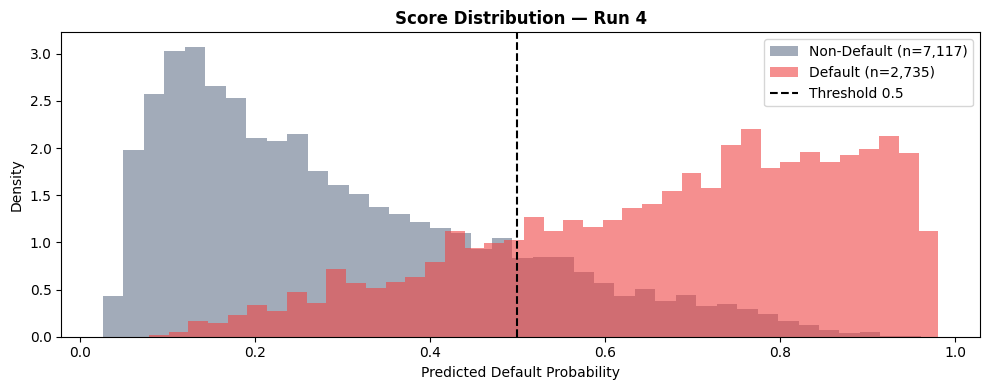

In [7]:
# How many batch runs have been scored, and what does the prediction distribution look like?
history = pd.read_sql("""
    SELECT run_index, COUNT(*) AS n_records,
           AVG(default_probability) AS avg_prob,
           AVG(CASE WHEN actual_default_flag IS NOT NULL THEN 1.0 ELSE 0.0 END) AS pct_labelled
    FROM dwh_history.prediction_ground_truth
    GROUP BY run_index ORDER BY run_index
""", engine)

print(f'Batch runs in production history: {len(history)}')
print(history.to_string(index=False))

if not history.empty:
    latest_run = int(history['run_index'].max())
    probs = pd.read_sql(
        f"SELECT default_probability, actual_default_flag "
        f"FROM dwh_history.prediction_ground_truth WHERE run_index = {latest_run}",
        engine,
    )
    fig, ax = plt.subplots(figsize=(10, 4))
    for outcome, color, label in [(0, '#64748b', 'Non-Default'), (1, '#ef4444', 'Default')]:
        sub = probs[probs['actual_default_flag'] == outcome]['default_probability'].dropna()
        if not sub.empty:
            ax.hist(sub, bins=40, alpha=0.6, color=color, label=f'{label} (n={len(sub):,})', density=True)
    unlabelled = probs['actual_default_flag'].isna()
    if unlabelled.any():
        ax.hist(probs[unlabelled]['default_probability'], bins=40,
                alpha=0.4, color='#94a3b8', label=f'Unlabelled (n={unlabelled.sum():,})', density=True)
    ax.axvline(0.5, color='black', linestyle='--', linewidth=1.5, label='Threshold 0.5')
    ax.set_xlabel('Predicted Default Probability')
    ax.set_ylabel('Density')
    ax.set_title(f'Score Distribution — Run {latest_run}', fontweight='bold')
    ax.legend()
    plt.tight_layout()
    plt.show()

## Next Steps

- Use `01_challenger_template.ipynb` to train and compare a new model against production
- Use `03_production_model_analysis.ipynb` to audit the current production model in detail